In [9]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load everything
df = pd.read_csv('/content/drive/MyDrive/aqua spatial/final_predictions.csv')
rf_model = joblib.load('/content/drive/MyDrive/aqua spatial/rf_model.pkl')
gb_model = joblib.load('/content/drive/MyDrive/aqua spatial/gb_model.pkl')

with open('/content/drive/MyDrive/aqua spatial/enugu_data.pkl', 'rb') as f:
    data = pickle.load(f)
enugu = data['enugu']

with open('/content/drive/MyDrive/aqua spatial/feature_list.pkl', 'rb') as f:
    FEATURES = pickle.load(f)

X = df[FEATURES].copy()

print(" Notebook 5 ready")
print(f"   LGAs: {len(df)}")
print(f"   Models: RF + GB loaded")
print(f"   Features: {len(FEATURES)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Notebook 5 ready
   LGAs: 17
   Models: RF + GB loaded
   Features: 17


Uncertainty Analysis

In [10]:
# --- Source 1: Model Disagreement ---
rf_preds = rf_model.predict(X)
gb_preds = gb_model.predict(X)
model_disagreement = np.abs(rf_preds - gb_preds)

# --- Source 2: Data Confidence ---
# More data points = lower uncertainty
# Using inverse square root — standard statistical formula
data_uncertainty = 1 / np.sqrt(df['total_points'].values)

# Normalize to 0-1 scale
data_uncertainty_norm = (data_uncertainty - data_uncertainty.min()) / \
                        (data_uncertainty.max() - data_uncertainty.min())

# --- Source 3: Random Forest Tree Variance ---
# Get prediction from each of the 200 trees individually
tree_predictions = np.array([tree.predict(X) for tree in rf_model.estimators_])
# Shape: (200 trees, 17 LGAs)
tree_std = tree_predictions.std(axis=0)  # Std across 200 trees per LGA

# Normalize to 0-1
tree_std_norm = (tree_std - tree_std.min()) / \
                (tree_std.max() - tree_std.min())

# --- Combine All 3 Sources ---
# Weighted combination — model disagreement most important
df['uncertainty_score'] = (
    model_disagreement   * 0.40 +  # Model disagreement
    data_uncertainty_norm * 0.35 + # Data reliability
    tree_std_norm        * 0.25    # Tree variance
).round(4)

# --- Confidence Bands ---
df['lower_bound'] = (df['predicted_stress'] - df['uncertainty_score']).clip(0, 1).round(4)
df['upper_bound'] = (df['predicted_stress'] + df['uncertainty_score']).clip(0, 1).round(4)

# --- Confidence Label ---
def confidence_label(score):
    if score < 0.08:   return 'High'
    elif score < 0.15: return 'Medium'
    else:              return 'Low'

df['confidence'] = df['uncertainty_score'].apply(confidence_label)

print(" Uncertainty quantification complete")
print(f"\n=== PREDICTIONS WITH CONFIDENCE INTERVALS ===")
print(df[['lga_name', 'predicted_stress', 'lower_bound',
          'upper_bound', 'uncertainty_score', 'confidence']]
      .sort_values('predicted_stress', ascending=False)
      .to_string(index=False))

print(f"\nConfidence distribution:")
print(df['confidence'].value_counts())

 Uncertainty quantification complete

=== PREDICTIONS WITH CONFIDENCE INTERVALS ===
     lga_name  predicted_stress  lower_bound  upper_bound  uncertainty_score confidence
    EnuguEast            0.5585       0.0000       1.0000             0.6095        Low
   EnuguSouth            0.5467       0.0795       1.0000             0.4672        Low
   EnuguNorth            0.4992       0.2310       0.7674             0.2682        Low
Igbo-ezeSouth            0.4969       0.2240       0.7698             0.2729        Low
          Udi            0.3830       0.2036       0.5624             0.1794        Low
   Igbo-Etiti            0.3729       0.0685       0.6773             0.3044        Low
    Uzo-Uwani            0.3685       0.0940       0.6430             0.2745        Low
      Isi-Uzo            0.3542       0.1932       0.5152             0.1610        Low
       Nsukka            0.3017       0.1410       0.4624             0.1607        Low
    Oji-River            0.2937     

Recalibrating confidence Threshords

In [11]:
# Look at actual uncertainty distribution
print("Uncertainty score distribution:")
print(df['uncertainty_score'].describe().round(4))

# Use percentiles instead of fixed thresholds
p33 = df['uncertainty_score'].quantile(0.33)
p66 = df['uncertainty_score'].quantile(0.66)

print(f"\nData-driven thresholds:")
print(f"   High confidence:   < {p33:.4f}")
print(f"   Medium confidence: {p33:.4f} — {p66:.4f}")
print(f"   Low confidence:    > {p66:.4f}")

# Reapply
def confidence_label_v2(score):
    if score < p33:  return 'High'
    elif score < p66: return 'Medium'
    else:             return 'Low'

df['confidence'] = df['uncertainty_score'].apply(confidence_label_v2)

print(f"\nRecalibrated confidence distribution:")
print(df['confidence'].value_counts())

print(f"\n=== FINAL RANKINGS WITH CALIBRATED CONFIDENCE ===")
print(df[['lga_name','predicted_stress','uncertainty_score',
          'lower_bound','upper_bound','confidence']]
      .sort_values('predicted_stress', ascending=False)
      .to_string(index=False))

Uncertainty score distribution:
count    17.0000
mean      0.2155
std       0.1472
min       0.0401
25%       0.1407
50%       0.1610
75%       0.2729
max       0.6095
Name: uncertainty_score, dtype: float64

Data-driven thresholds:
   High confidence:   < 0.1602
   Medium confidence: 0.1602 — 0.2518
   Low confidence:    > 0.2518

Recalibrated confidence distribution:
confidence
Low       6
High      6
Medium    5
Name: count, dtype: int64

=== FINAL RANKINGS WITH CALIBRATED CONFIDENCE ===
     lga_name  predicted_stress  uncertainty_score  lower_bound  upper_bound confidence
    EnuguEast            0.5585             0.6095       0.0000       1.0000        Low
   EnuguSouth            0.5467             0.4672       0.0795       1.0000        Low
   EnuguNorth            0.4992             0.2682       0.2310       0.7674        Low
Igbo-ezeSouth            0.4969             0.2729       0.2240       0.7698        Low
          Udi            0.3830             0.1794       0.2036 

Uncertainty Visualisation

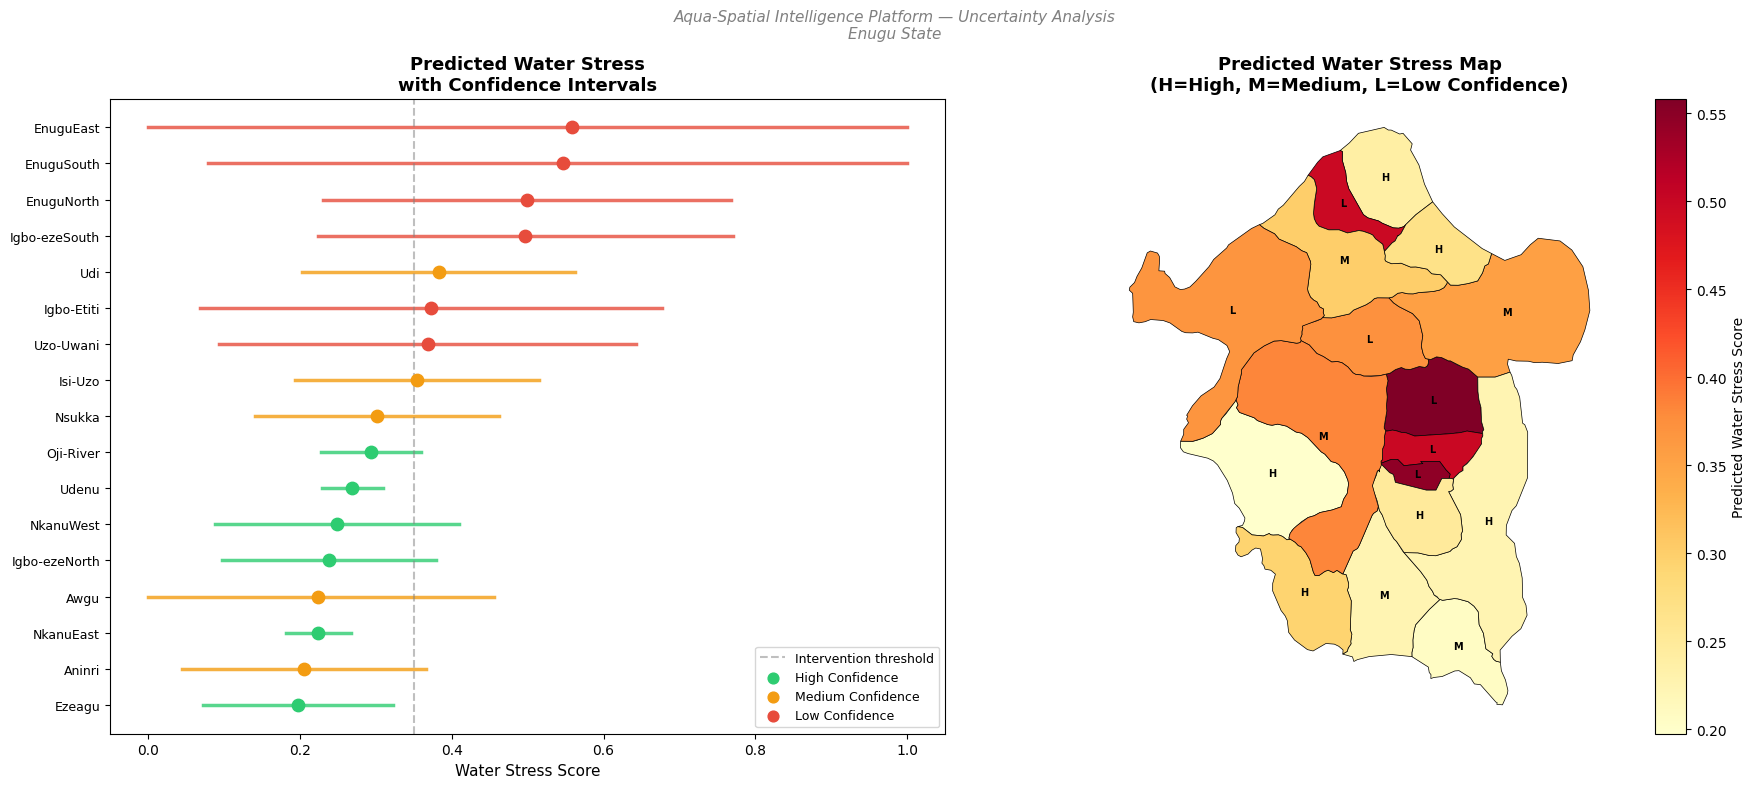

 Uncertainty visualisation saved


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Confidence Interval Chart ---
sorted_df = df.sort_values('predicted_stress', ascending=True).reset_index(drop=True)

colors = {'High': '#2ecc71', 'Medium': '#f39c12', 'Low': '#e74c3c'}
conf_colors = [colors[c] for c in sorted_df['confidence']]

# Plot confidence intervals as horizontal lines
for i, row in sorted_df.iterrows():
    axes[0].plot(
        [row['lower_bound'], row['upper_bound']],
        [i, i],
        color=colors[row['confidence']],
        linewidth=2.5,
        alpha=0.8
    )
    # Plot predicted value as dot
    axes[0].scatter(
        row['predicted_stress'], i,
        color=colors[row['confidence']],
        s=80, zorder=5
    )

axes[0].set_yticks(range(len(sorted_df)))
axes[0].set_yticklabels(sorted_df['lga_name'], fontsize=9)
axes[0].set_xlabel('Water Stress Score', fontsize=11)
axes[0].set_title('Predicted Water Stress\nwith Confidence Intervals',
                   fontsize=13, fontweight='bold')
axes[0].axvline(x=0.35, color='grey', linestyle='--',
                alpha=0.5, label='Intervention threshold')
axes[0].legend()

# Legend
for label, color in colors.items():
    axes[0].scatter([], [], color=color, label=f'{label} Confidence', s=60)
axes[0].legend(loc='lower right', fontsize=9)

# --- Plot 2: Choropleth — Predicted Stress ---
enugu_plot = enugu.merge(
    df[['lga_name','predicted_stress','confidence']],
    left_on='NAME_2', right_on='lga_name', how='left'
)

enugu_plot.plot(
    column='predicted_stress',
    ax=axes[1],
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': 'Predicted Water Stress Score'}
)

# Annotate each LGA with confidence label
for _, row in enugu_plot.iterrows():
    centroid = row.geometry.centroid
    conf = row.get('confidence', '')
    conf_short = {'High': 'H', 'Medium': 'M', 'Low': 'L'}.get(conf, '')
    axes[1].annotate(
        conf_short,
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=7, fontweight='bold',
        color='black'
    )

axes[1].set_title('Predicted Water Stress Map\n(H=High, M=Medium, L=Low Confidence)',
                   fontsize=13, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('Aqua-Spatial Intelligence Platform — Uncertainty Analysis\nEnugu State',
             fontsize=11, style='italic', color='grey')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/aqua spatial/uncertainty_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(" Uncertainty visualisation saved")

In [13]:
df.to_csv('/content/drive/MyDrive/aqua spatial/final_predictions.csv', index=False)

# Also save a clean summary for the dashboard
dashboard_df = df[[
    'lga_name', 'predicted_stress', 'lower_bound', 'upper_bound',
    'uncertainty_score', 'confidence', 'target_stress_score',
    'functionality_rate', 'total_stress_rate', 'avg_depth_m',
    'area_km2', 'total_pop_served', 'ndvi', 'soil_moisture',
    'elevation', 'slope', 'lst_celsius', 'heat_veg_stress',
    'terrain_difficulty', 'drilling_difficulty', 'total_points'
]].copy()

dashboard_df.to_csv('/content/drive/MyDrive/aqua spatial/dashboard_data.csv', index=False)

print(" Final predictions saved")
print(" Dashboard data saved")
print(f"\nDashboard columns: {dashboard_df.columns.tolist()}")
print(f"\nReady for Streamlit. Summary:")
print(dashboard_df[['lga_name','predicted_stress','confidence']]
      .sort_values('predicted_stress', ascending=False)
      .to_string(index=False))

 Final predictions saved
 Dashboard data saved

Dashboard columns: ['lga_name', 'predicted_stress', 'lower_bound', 'upper_bound', 'uncertainty_score', 'confidence', 'target_stress_score', 'functionality_rate', 'total_stress_rate', 'avg_depth_m', 'area_km2', 'total_pop_served', 'ndvi', 'soil_moisture', 'elevation', 'slope', 'lst_celsius', 'heat_veg_stress', 'terrain_difficulty', 'drilling_difficulty', 'total_points']

Ready for Streamlit. Summary:
     lga_name  predicted_stress confidence
    EnuguEast            0.5585        Low
   EnuguSouth            0.5467        Low
   EnuguNorth            0.4992        Low
Igbo-ezeSouth            0.4969        Low
          Udi            0.3830     Medium
   Igbo-Etiti            0.3729        Low
    Uzo-Uwani            0.3685        Low
      Isi-Uzo            0.3542     Medium
       Nsukka            0.3017     Medium
    Oji-River            0.2937       High
        Udenu            0.2691       High
    NkanuWest            0.2490  